<a href="https://colab.research.google.com/github/dhanushkaputty/DL/blob/main/week13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision transformers datasets

In [2]:
import torch
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, vocab_size, embed_size, heads, hidden_dim, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=embed_size,
                nhead=heads,
                dim_feedforward=hidden_dim,
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.fc = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        return self.fc(out)

vocab_size = 20
model = TransformerModel(vocab_size, 32, 4, 64, 2)

x = torch.randint(0, vocab_size, (2, 5))
output = model(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 5])
Output shape: torch.Size([2, 5, 20])


BERT – Predicting Missing Word

In [3]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased")

sentence = "I love studying [MASK] learning."

results = fill_mask(sentence)

print("Sentence:", sentence)
print("Top predictions:")

for r in results[:5]:
    print(r["sequence"], " | Score:", round(r["score"], 4))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sentence: I love studying [MASK] learning.
Top predictions:
i love studying and learning.  | Score: 0.9719
i love studying, learning.  | Score: 0.0214
i love studying. learning.  | Score: 0.0013
i love studying & learning.  | Score: 0.0009
i love studying - learning.  | Score: 0.0009


BERT – Predicting Next Word Style

In [4]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased")

sentence = "Artificial intelligence is changing the [MASK]."

results = fill_mask(sentence)

print("Input:", sentence)
print("Predicted next word options:")

for r in results[:5]:
    print(r["token_str"], "=>", r["sequence"])

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Input: Artificial intelligence is changing the [MASK].
Predicted next word options:
world => artificial intelligence is changing the world.
universe => artificial intelligence is changing the universe.
landscape => artificial intelligence is changing the landscape.
game => artificial intelligence is changing the game.
future => artificial intelligence is changing the future.


BERT – Review Classification

In [5]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

review = "This product is very good and useful. I really liked it."

result = classifier(review)

print("Review:", review)
print("Classification:", result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Review: This product is very good and useful. I really liked it.
Classification: [{'label': 'POSITIVE', 'score': 0.9998809099197388}]


ViT Model

In [6]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

url = "https://images.unsplash.com/photo-1518717758536-85ae29035b6d?w=300"
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)

predicted_class = outputs.logits.argmax(-1).item()

print("Predicted class ID:", predicted_class)
print("Predicted label:", model.config.id2label[predicted_class])

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted class ID: 210
Predicted label: German short-haired pointer


GAN on MNIST

100%|██████████| 9.91M/9.91M [00:00<00:00, 52.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


Epoch [1/3] D Loss: 0.8759 G Loss: 1.2062
Epoch [2/3] D Loss: 0.6746 G Loss: 1.5513
Epoch [3/3] D Loss: 1.2352 G Loss: 0.8917


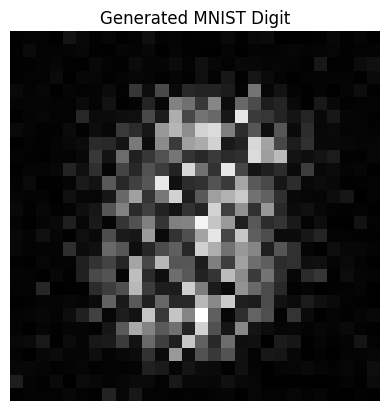

In [7]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

latent_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

epochs = 3

for epoch in range(epochs):
    for real, _ in loader:
        real = real.view(-1, 784).to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size, latent_dim).to(device)
        fake = G(z)

        real_loss = loss_fn(D(real), real_labels)
        fake_loss = loss_fn(D(fake.detach()), fake_labels)
        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # Train Generator
        z = torch.randn(batch_size, latent_dim).to(device)
        fake = G(z)
        g_loss = loss_fn(D(fake), real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.item():.4f} G Loss: {g_loss.item():.4f}")

# Generate sample image
z = torch.randn(1, latent_dim).to(device)
generated = G(z).view(28, 28).detach().cpu()

plt.imshow(generated, cmap="gray")
plt.title("Generated MNIST Digit")
plt.axis("off")
plt.show()